In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sb
import wave

In [2]:
audioParams = None
audioData = None

In [3]:
with open('test.wav', 'rb') as f:
    wover = wave.Wave_read(f)
    frames = wover.getnframes()
    audioData = wover.readframes(frames)
    audioParams = wover.getparams()

In [4]:
samples = pd.DataFrame(data = np.frombuffer(audioData, dtype=np.dtype('int'+str(8*audioParams.sampwidth)), count=-1),
                       index = pd.RangeIndex(name='time', start=0, stop=audioParams.nframes, step=1)/audioParams.framerate,
                       columns = ['amplitude'])
samples

,amplitude
time,
0.000000,11
0.000023,9
0.000045,1
0.000068,-4
0.000091,-12
...,...
0.679705,-6
0.679728,-7
0.679751,-7


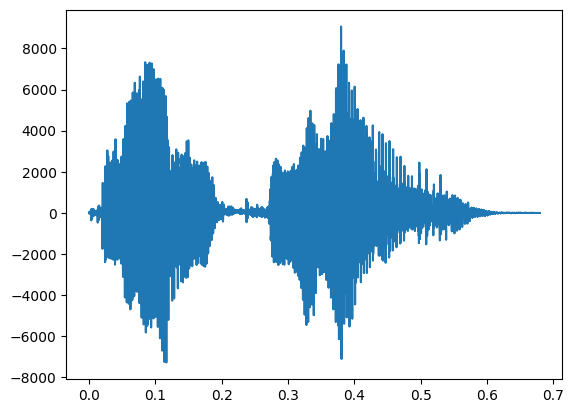

In [5]:
plt.plot(samples)

In [6]:
samples['normalized'] = samples['amplitude'] / (2 ** (8 * audioParams.sampwidth - 1))

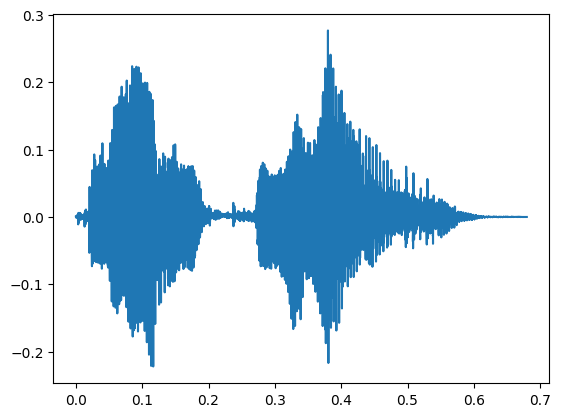

In [7]:
plt.plot(samples['normalized'])

In [8]:
samples

,amplitude,normalized
time,,
0.000000,11,0.000336
0.000023,9,0.000275
0.000045,1,0.000031
0.000068,-4,-0.000122
0.000091,-12,-0.000366
...,...,...
0.679705,-6,-0.000183
0.679728,-7,-0.000214
0.679751,-7,-0.000214


In [9]:
win = sp.signal.windows.hann(int(0.0025 * audioParams.framerate))
ffter = sp.signal.ShortTimeFFT(win = win, hop=len(win)//2, fs=audioParams.framerate)

In [10]:
spectrogram_data = ffter.stft(np.array(samples['normalized']))

In [11]:
spectrogram = pd.DataFrame(spectrogram_data,
                           index= pd.RangeIndex(name='Frequency Bins', start=0, stop=spectrogram_data.shape[0], step=1) * 2 * np.pi / (spectrogram_data.shape[0] - 1),
                           columns=pd.RangeIndex(name='Time Bins', start=0, stop=spectrogram_data.shape[1], step=1) / spectrogram_data.shape[1] * audioParams.nframes / audioParams.framerate )

In [12]:
spectrogram

Time Bins,0.000000,0.001243,0.002486,0.003728,0.004971,0.006214,0.007457,0.008700,0.009943,0.011185,...,0.667390,0.668633,0.669876,0.671119,0.672362,0.673605,0.674847,0.676090,0.677333,0.678576
Frequency Bins,,,,,,,,,,,,,,,,,,,,,
0.000000,-0.004579+0.000000j,0.005219+0.000000j,-0.008207+0.000000j,-0.014713+0.000000j,0.036617+0.000000j,0.008777+0.000000j,-0.018381+0.000000j,-0.007411+0.000000j,-0.002584+0.000000j,0.044218+0.000000j,...,-0.006671+0.000000j,-0.005676+0.000000j,-0.003722+0.000000j,-0.007007+0.000000j,-0.009619+0.000000j,-0.009407+0.000000j,-0.012531+0.000000j,-0.013106+0.000000j,-0.006690+0.000000j,-4.498715e-06+0.000000e+00j
0.114240,-0.005507+0.001829j,-0.000700+0.002009j,0.031449+0.048591j,0.035750-0.110440j,0.022269-0.085917j,-0.029368-0.043007j,-0.053084-0.022571j,-0.038083-0.013940j,-0.032160+0.014644j,-0.000594-0.005674j,...,-0.003349+0.000259j,-0.002652-0.001608j,-0.001704-0.000544j,-0.003626+0.001212j,-0.004872-0.000409j,-0.004360+0.000349j,-0.006457+0.000502j,-0.006712-0.000112j,-0.003511-0.003724j,4.417998e-06-8.199432e-07j
0.228479,-0.003565+0.005546j,-0.004232+0.010293j,0.039126+0.010383j,0.067008-0.136950j,0.022567-0.137778j,-0.051237-0.074407j,-0.074622-0.062830j,-0.055463-0.022896j,-0.049602+0.017479j,-0.049418+0.023549j,...,-0.000044-0.000370j,0.000373-0.001455j,0.000421-0.000834j,-0.000054+0.000107j,0.000257-0.000238j,0.000539+0.000179j,0.000057+0.000388j,-0.000108+0.000669j,-0.000558-0.002092j,-4.179317e-06+1.607072e-06j
0.342719,-0.000125+0.005604j,-0.000499+0.006749j,0.007609+0.001790j,0.055568-0.043472j,0.049642-0.047873j,-0.009500-0.003597j,-0.030814-0.038901j,-0.023925-0.004462j,-0.022537+0.009014j,-0.034687+0.026207j,...,-0.000041-0.000421j,0.000038-0.000420j,0.000251-0.000306j,-0.000163-0.000433j,0.000329+0.000033j,0.000240+0.000019j,0.000140+0.000167j,-0.000119+0.000799j,-0.000699-0.000758j,3.792927e-06-2.330054e-06j
0.456959,0.001264+0.005776j,-0.000868-0.000101j,0.015903+0.004037j,0.082041+0.027764j,0.053877+0.046748j,0.008994+0.048425j,-0.005292+0.007021j,-0.010986+0.012876j,-0.011854+0.009005j,-0.014031+0.010147j,...,0.000121-0.000139j,-0.000343+0.000637j,-0.000132-0.000109j,-0.000374-0.000123j,0.000041-0.000162j,0.000076+0.000064j,-0.000324+0.000469j,-0.000051+0.000377j,-0.000671-0.000453j,-3.275383e-06+2.960452e-06j
0.571199,0.005487+0.005508j,0.000258-0.003413j,0.004970-0.004299j,0.062307+0.025324j,0.023049+0.035925j,0.000416+0.023943j,-0.005804+0.005246j,-0.010579+0.006951j,-0.008602+0.007806j,-0.005014+0.000326j,...,0.000059-0.000235j,-0.000661+0.001109j,-0.000091-0.000391j,-0.000085-0.000192j,0.000129-0.000603j,-0.000231+0.000080j,-0.000425+0.001145j,0.000512+0.000346j,-0.000635-0.000140j,2.648768e-06-3.473993e-06j
0.685438,0.007729-0.000051j,0.005943+0.000343j,-0.003410+0.009623j,-0.000289+0.024172j,0.003838-0.003241j,0.001446-0.000357j,0.002653-0.002736j,-0.004921+0.002169j,-0.002886+0.001981j,0.004050-0.002553j,...,-0.000199+0.000479j,-0.000882+0.000820j,-0.000220-0.000608j,0.000287-0.000415j,0.000214-0.000585j,-0.000141+0.000234j,-0.000423+0.001163j,0.000667+0.000705j,-0.000633+0.000040j,-1.939665e-06+3.851642e-06j
0.799678,0.004091-0.003698j,0.006623+0.003459j,0.004204+0.005069j,-0.023599+0.026506j,0.011451-0.008136j,0.000367-0.003569j,0.003697+0.000121j,-0.004644+0.001199j,-0.004677+0.002011j,0.004754+0.000471j,...,-0.000420+0.001120j,-0.000415+0.000550j,-0.000395-0.000569j,0.000291-0.000200j,0.000122-0.000306j,0.000302+0.000102j,-0.000424+0.000302j,0.000489+0.000438j,-0.000628+0.000006j,1.177922e-06-4.080426e-06j
0.913918,0.001347-0.003203j,0.002954+0.001368j,0.001477-0.000294j,-0.017056+0.014929j,0.008578+0.002384j,-0.001010-0.001627j,-0.000977-0.000426j,-0.002353-0.000593j,-0.002610+0.003967j,0.000466+0.003090j,...,-0.000267+0.000693j,-0.000109+0.000522j,-0.000237-0.000200j,0.000011+0.000046j,0.000028-0.000146j,0.000209-0.000216j,-0.000274-0.000179j,0.000325-0.000111j,-0.000282-0.000014j,-3.952690e-07+4.153967e-06j


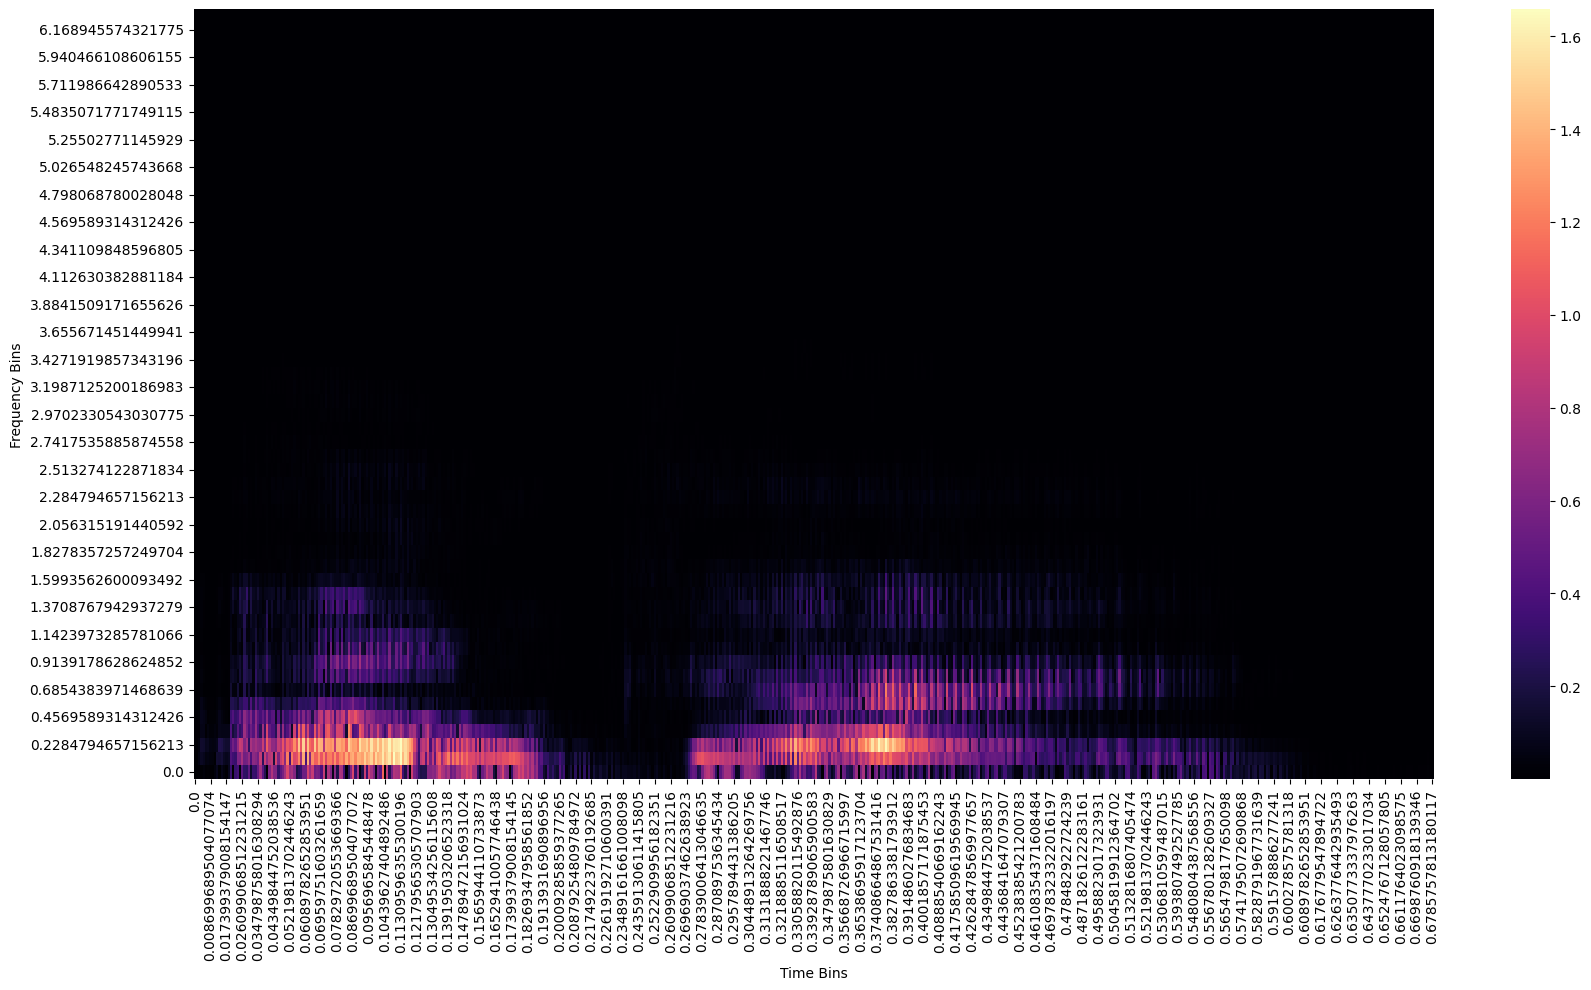

In [13]:
fig = plt.figure(figsize=(20, 10))
ax = sb.heatmap(np.log(np.absolute(spectrogram) + 1), cmap='magma')
ax.invert_yaxis()

In [14]:
spectrogram_data

array([[-4.57868214e-03+0.00000000e+00j,  5.21918083e-03+0.00000000e+00j,
        -8.20686033e-03+0.00000000e+00j, ...,
        -1.31063524e-02+0.00000000e+00j, -6.68985613e-03+0.00000000e+00j,
        -4.49871524e-06+0.00000000e+00j],
       [-5.50654497e-03+1.82861761e-03j, -7.00006143e-04+2.00854904e-03j,
         3.14493262e-02+4.85905223e-02j, ...,
        -6.71207657e-03-1.11820520e-04j, -3.51106998e-03-3.72351236e-03j,
         4.41799771e-06-8.19943175e-07j],
       [-3.56522173e-03+5.54588416e-03j, -4.23245846e-03+1.02929515e-02j,
         3.91260415e-02+1.03834577e-02j, ...,
        -1.07650662e-04+6.69362579e-04j, -5.58233263e-04-2.09166920e-03j,
        -4.17931713e-06+1.60707196e-06j],
       ...,
       [ 9.72074559e-05+1.74677541e-05j,  1.08326845e-04-2.97102179e-05j,
         8.34237923e-06-5.63164434e-05j, ...,
        -5.67705802e-05-3.11020957e-05j, -4.34241769e-05-4.33462845e-06j,
         8.25827116e-07+4.95876320e-07j],
       [ 1.65701839e-04+7.20693072e-05j,  5.

In [15]:
audioParams.nframes * 0.0625

1873.75

In [16]:
[0.5 ** i for i in range(10)]

[1.0,
 0.5,
 0.25,
 0.125,
 0.0625,
 0.03125,
 0.015625,
 0.0078125,
 0.00390625,
 0.001953125]

In [17]:
def getBlocks(n):
    a = []
    for i in range(n):
        win = sp.signal.windows.hann(int(0.5 ** i * audioParams.framerate))
        ffter = sp.signal.ShortTimeFFT(win = win, hop=len(win)//2, fs=audioParams.framerate)
        a.append(ffter)
    return a

In [27]:
def convertToBloop(ffter):
    spec_data = ffter.stft(np.array(samples['normalized']))
    x = samples.index

    d = []
    for k in range(spec_data.shape[0]):
        xp = pd.RangeIndex(name='Time Bins', start=0, stop=spec_data.shape[1], step=1) / spec_data.shape[1] * audioParams.nframes / audioParams.framerate
        y = np.interp(x, xp, spec_data[k])
        d.append(y)

    return np.array(d)

In [28]:
fffff = getBlocks(10)
convertToBloop(fffff[0])

array([[ 1.51060185e+00+0.00000000e+00j,  1.51068212e+00+0.00000000e+00j,
         1.51076239e+00+0.00000000e+00j, ...,
        -1.10449382e-01+0.00000000e+00j, -1.10449382e-01+0.00000000e+00j,
        -1.10449382e-01+0.00000000e+00j],
       [-8.05872082e-01-3.46780092e+00j, -8.05773322e-01-3.46737093e+00j,
        -8.05674562e-01-3.46694095e+00j, ...,
         7.44682964e-02-7.76083026e-02j,  7.44682964e-02-7.76083026e-02j,
         7.44682964e-02-7.76083026e-02j],
       [-6.93666018e+00-1.81270873e+00j, -6.93575396e+00-1.81289947e+00j,
        -6.93484775e+00-1.81309022e+00j, ...,
         4.20693852e-03+9.89787916e-02j,  4.20693852e-03+9.89787916e-02j,
         4.20693852e-03+9.89787916e-02j],
       ...,
       [-1.81771645e-03+4.52895919e-04j, -1.81744419e-03+4.52944154e-04j,
        -1.81717193e-03+4.52992390e-04j, ...,
        -9.61664702e-05+1.39655092e-04j, -9.61664702e-05+1.39655092e-04j,
        -9.61664702e-05+1.39655092e-04j],
       [-1.00176284e-03+2.80227658e-04j, -1.

In [18]:
specdat = [k.stft(np.array(samples['normalized'])) for k in getBlocks(10)]
specdat

[array([[ 1.51060185e+00+0.00000000e+00j,  2.31274311e+00+0.00000000e+00j,
         -1.10449382e-01+0.00000000e+00j],
        [-8.05872082e-01-3.46780092e+00j,  1.81071278e-01+8.29203660e-01j,
          7.44682964e-02-7.76083026e-02j],
        [-6.93666018e+00-1.81270873e+00j,  2.11947518e+00-3.71887642e+00j,
          4.20693852e-03+9.89787916e-02j],
        ...,
        [-1.81771645e-03+4.52895919e-04j,  9.03092833e-04+9.34926916e-04j,
         -9.61664702e-05+1.39655092e-04j],
        [-1.00176284e-03+2.80227658e-04j,  6.02332094e-04+6.29427513e-04j,
         -7.55128718e-05-1.45895800e-04j],
        [-9.71601746e-04+0.00000000e+00j,  8.70286029e-04+0.00000000e+00j,
          1.62333121e-04+0.00000000e+00j]], shape=(22051, 3)),
 array([[-2.21126831e+00+0.00000000e+00j,  4.63350819e+00+0.00000000e+00j,
          1.66076501e+00+0.00000000e+00j, -3.69845146e-01+0.00000000e+00j],
        [-2.81434565e+00+1.90774710e+00j,  6.03943675e+00+7.53606796e+00j,
          4.04241132e+00-1.360349

In [19]:
specdat[0].shape

(22051, 3)

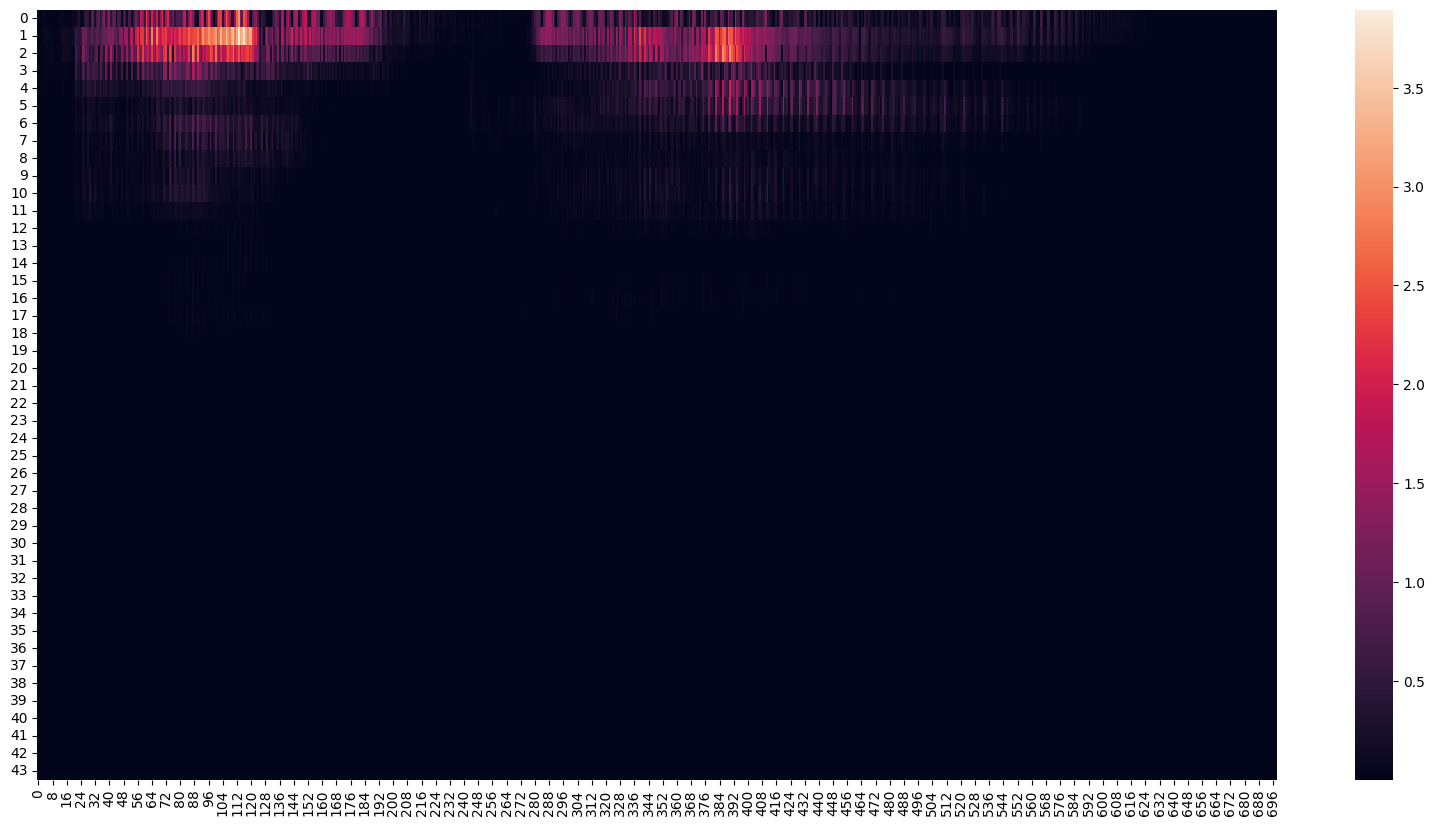

In [41]:
fig = plt.figure(figsize=(20, 10))
sb.heatmap(np.absolute(specdat[9]))
plt.show()